--- Optimization Results (10000 Evaluations | Pop Size: 50) ---
GD:  0.0507
IGD: 0.0970
HV:  690.6075
Pareto Points: 50/10000 (0.50%)
Spread (Delta): 0.5578


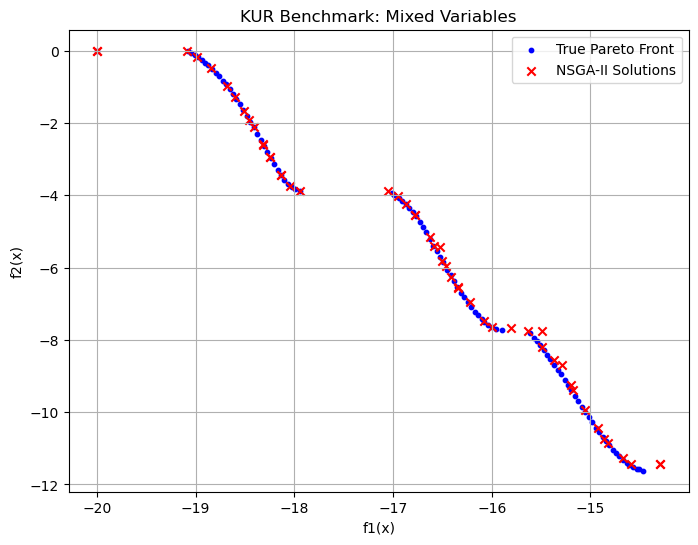

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.indicators.gd import GD
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from pymoo.problems import get_problem

# Experiment Parameters
pop_size = 50
total_evals = 10000
n_gen = 16

# KUR Problem with Mixed Variables
class KUR(Problem):
    def __init__(self):
        super().__init__(n_var=3, n_obj=2, xl=[-5.0]*3, xu=[5.0]*3)

    def _evaluate(self, x, out, *args, **kwargs):
        # Discretize the first two variables to a 0.1 step size
        x[:, 0:2] = np.round(x[:, 0:2] * 10) / 10
        
        # Calculate f1
        f1 = -10 * np.exp(-0.2 * np.sqrt(x[:, 0]**2 + x[:, 1]**2)) \
             -10 * np.exp(-0.2 * np.sqrt(x[:, 1]**2 + x[:, 2]**2))
        
        # Calculate f2
        f2 = np.sum(np.abs(x)**0.8 + 5 * np.sin(x**3), axis=1)
        
        out["F"] = np.column_stack([f1, f2])

# Run NSGA-II
res = minimize(KUR(), NSGA2(pop_size=pop_size), ('n_evals', total_evals), seed=42, verbose=False)

# Fetch True Pareto Front directly from pymoo
pf_true = get_problem("kursawe").pareto_front()

# Quality Indicators and Visualization
if res.F is not None:
    print(f"--- Optimization Results ({total_evals} Evaluations | Pop Size: {pop_size}) ---")
    print(f"GD:  {GD(pf_true)(res.F):.4f}")
    print(f"IGD: {IGD(pf_true)(res.F):.4f}")
    print(f"HV:  {HV(ref_point=np.array([0.0, 25.0]))(res.F):.4f}")
    print(f"Pareto Points: {len(res.F)}/{total_evals} ({(len(res.F) / total_evals) * 100:.2f}%)")

    # Spread (Delta) — guarded against single-point fronts
    F = res.F[np.argsort(res.F[:, 0])]
    if len(F) < 2:
        print("Spread (Delta): N/A (insufficient Pareto points)")
    else:
        d_i = np.linalg.norm(np.diff(F, axis=0), axis=1)
        d_bar = d_i.mean()
        df = np.linalg.norm(pf_true[0]  - F[0])
        dl = np.linalg.norm(pf_true[-1] - F[-1])
        denom = df + dl + (len(F) - 1) * d_bar
        spread = (df + dl + np.sum(np.abs(d_i - d_bar))) / denom if denom > 0 else float('nan')
        print(f"Spread (Delta): {spread:.4f}")

    # Visualization
    plt.figure(figsize=(8, 6))
    plt.scatter(pf_true[:, 0], pf_true[:, 1], label="True Pareto Front", color="blue", s=10)
    plt.scatter(res.F[:, 0], res.F[:, 1], label="NSGA-II Solutions", color="red", marker="x")
    plt.title("KUR Benchmark: Mixed Variables")
    plt.xlabel("f1(x)")
    plt.ylabel("f2(x)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No feasible solutions found.")